In [1]:

# 1. Data Loading & Initial Inspection

import pandas as pd

# Load the dataset
df = pd.read_csv("/content/heart_disease_kaggle.csv")

# Display first rows
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,73,1,2,119,385,0,0,196,0,1.9,2,2,3,1
1,76,1,2,118,472,0,1,170,0,3.8,2,2,2,1
2,29,1,0,133,556,1,0,97,1,2.6,2,2,1,1
3,32,1,3,122,248,1,0,174,0,4.1,0,2,2,0
4,32,1,2,118,539,1,1,143,0,0.9,2,0,3,0


In [2]:
# Dataset shape and information
print("Dataset Shape:", df.shape)
df.info()
df.describe()


Dataset Shape: (303, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.00000,303.000000,303.000000,303.000000
mean,52.712871,0.514851,1.448845,145.547855,346.904290,0.508251,0.501650,134.666667,0.541254,3.103300,1.00330,1.636964,2.003300,0.521452
std,14.609715,0.500606,1.050003,33.017307,123.171181,0.500759,0.500824,38.598860,0.499120,1.805691,0.85544,1.124775,0.835862,0.500366
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.00000,0.000000,1.000000,0.000000
25%,40.000000,0.000000,1.000000,115.000000,238.000000,0.000000,0.000000,100.000000,0.000000,1.600000,0.00000,1.000000,1.000000,0.000000
50%,53.000000,1.000000,1.000000,144.000000,342.000000,1.000000,1.000000,134.000000,1.000000,3.200000,1.00000,2.000000,2.000000,1.000000
75%,65.000000,1.000000,2.000000,176.500000,448.500000,1.000000,1.000000,168.500000,1.000000,4.700000,2.00000,3.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,199.000000,561.000000,1.000000,1.000000,201.000000,1.000000,6.100000,2.00000,3.000000,3.000000,1.000000


In [3]:
# 2. Data Cleaning & Preparation

# Check for missing values
print(df.isnull().sum())

# No missing values found, so no imputation is required

# Check for categorical features
categorical_cols = df.select_dtypes(include=['object']).columns
print("Categorical Columns:", categorical_cols)
# No categorical features found, so encoding is not required


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
Categorical Columns: Index([], dtype='object')


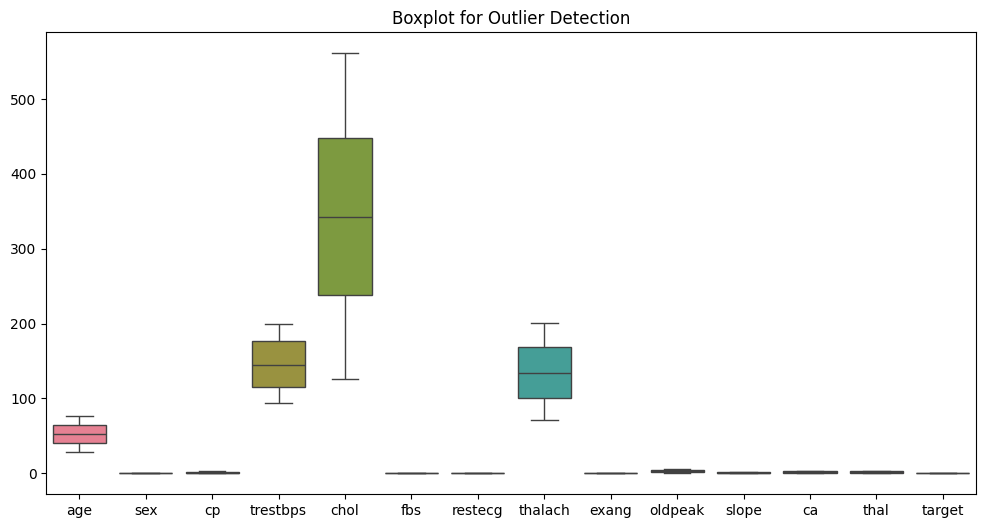

In [4]:
# Outlier Detection
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.title("Boxplot for Outlier Detection")
plt.show()


In [5]:
# 3. Feature Selection

# Define features and target
X = df.drop("target", axis=1)
y = df["target"]


In [6]:
# 4. Data Splitting

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (242, 13)
Testing set size: (61, 13)


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
